Utilizzando il dataset Diabetes, replica l'esercitazione pratica in Python:
- Addestra un modello RandomForestRegressor (max_depth=10 & n_estimators=100)
- Plottare un grafico a barre per l'importanza delle feature in ordine decrescente
- Stampare le prime 5 feature più importanti
- Visualizzare il diagramma strutturale dell'ultimo albero del Random Forest

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import load_diabetes

In [7]:
diabetes=load_diabetes()
X,y=diabetes.data, diabetes.target
feature_name=diabetes.feature_names
print(X.shape)
print(feature_name)
print(X[:5])
print(y.shape)

(442, 10)
['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235  -0.03482076
  -0.04340085 -0.00259226  0.01990749 -0.01764613]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872 -0.01916334
   0.07441156 -0.03949338 -0.06833155 -0.09220405]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945 -0.03419447
  -0.03235593 -0.00259226  0.00286131 -0.02593034]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057  0.02499059
  -0.03603757  0.03430886  0.02268774 -0.00936191]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485  0.01559614
   0.00814208 -0.00259226 -0.03198764 -0.04664087]]
(442,)


REGRESSIONE

In [24]:
rf_regressor=RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_regressor.fit(X,y)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Importanza delle Feature

In [25]:
importance=rf_regressor.feature_importances_
indices=np.argsort(importance)[::-1]
print(importance)
print(indices)

[0.0563912  0.01183485 0.2790864  0.08542094 0.04390691 0.05657693
 0.04998677 0.02624725 0.3204335  0.07011524]
[8 2 3 9 5 0 6 4 7 1]


Plot

In [27]:

print(f"Prime 5 feature più importanti: {np.array(feature_name)[indices[:5]]}")
print(f"Importanza Feature")
for i in range(5):
    print(f"{i + 1} - {feature_name[indices[i]]}:\t{importance[indices[i]]:.3f}")


Prime 5 feature più importanti: ['s5' 'bmi' 'bp' 's6' 's2']
Importanza Feature
1 - s5:	0.320
2 - bmi:	0.279
3 - bp:	0.085
4 - s6:	0.070
5 - s2:	0.057


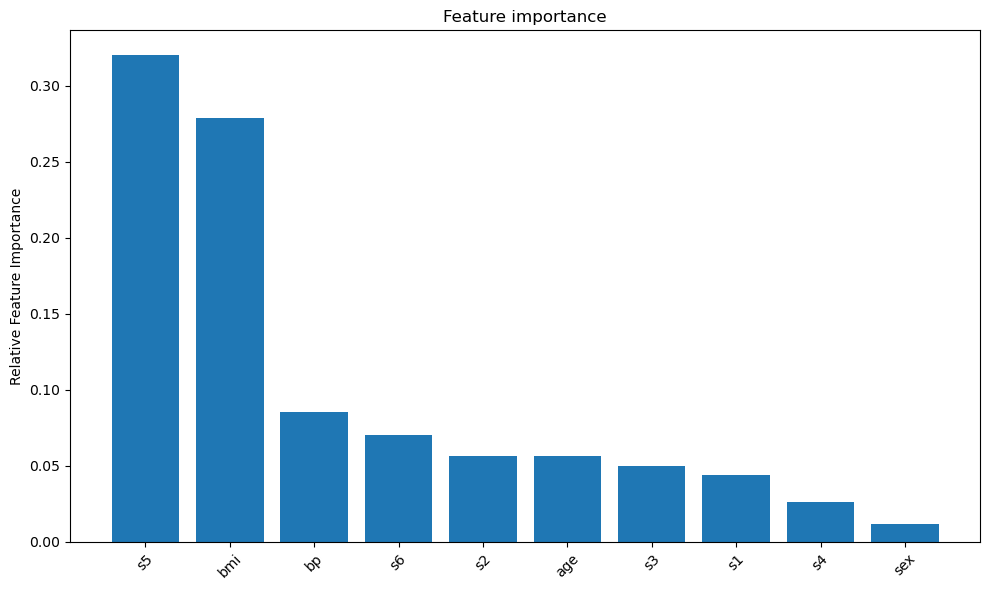

In [28]:
plt.figure(figsize=(10,6))
plt.title("Feature importance")
plt.bar(range(X.shape[1]),importance[indices],align="center")
plt.xticks(range(X.shape[1]),np.array(feature_name)[indices],rotation=45,ha="center")
plt.ylabel("Relative Feature Importance")
plt.tight_layout()
plt.show()


Visualizzo gli alberi decisionali

Total Estimator: [DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=1608637542), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=1273642419), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=1935803228), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=787846414), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=996406378), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=1201263687), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=423734972), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=415968276), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=670094950), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=1914837113), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=669991378), DecisionTreeRegressor(max_depth=10, max_features=1.0, random_state=429389014), DecisionTreeRegressor(max_dep

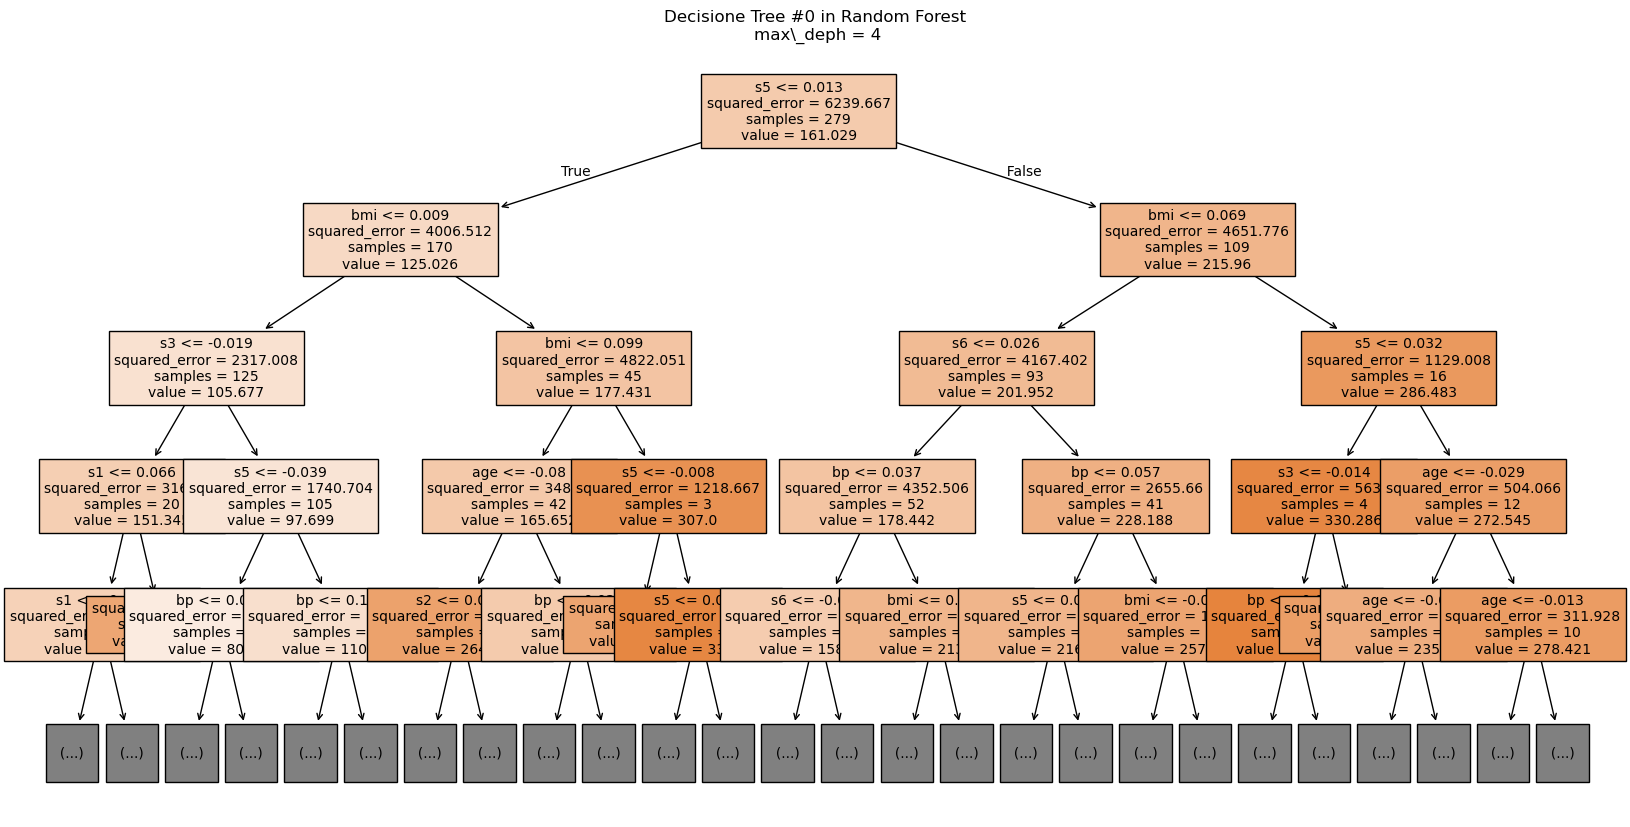

In [31]:
tree_num=-1
max_depth=4
estimator=rf_regressor.estimators_[tree_num]
print(f"Total Estimator: {rf_regressor.estimators_}")
plt.figure(figsize=(20,10))
plot_tree(
    estimator,
    feature_names=feature_name,
    max_depth=max_depth,
    filled=True,
    fontsize=10,
)
plt.title(f"Decisione Tree #{tree_num+1} in Random Forest \nmax\\_deph = {max_depth}")
plt.show()